In [ ]:
pip install tensorflow rasterio xarray rioxarray geopandas pystac-client planetary-computer pystac keras-tuner rasterstats xgboost lightgbm shap #install all neccessary stuff as google collab dont come with these features

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.2/194.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 63.5 MB/s eta 0:00:00


## Import All Neccessary File

In [ ]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets
import xarray as xr

# Geospatial raster data handling
import rioxarray as rxr

# Geospatial data analysis
import geopandas as gpd

# Geospatial operations
import rasterio
from rasterio import windows
from rasterio import features
from rasterio import warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

# Image Processing
from PIL import Image

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

#CNN-LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed

# Planetary Computer Tools
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# Others
import os
from tqdm import tqdm

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import randint
from rasterio.enums import Resampling
from scipy import stats

# Import the training data. (the training data is in my google drive, so i just do this instead)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Now you can access files from your Google Drive
file_path = '/content/drive/My Drive/DATA/Training_data_uhi_index_2025-02-18.csv'  # Update with your file's path in Drive
df = pd.read_csv(file_path)

Mounted at /content/drive


In [ ]:
df.head()

In [ ]:
df.describe()

# Weather Data Extraction

#Sentinel Data Extraction

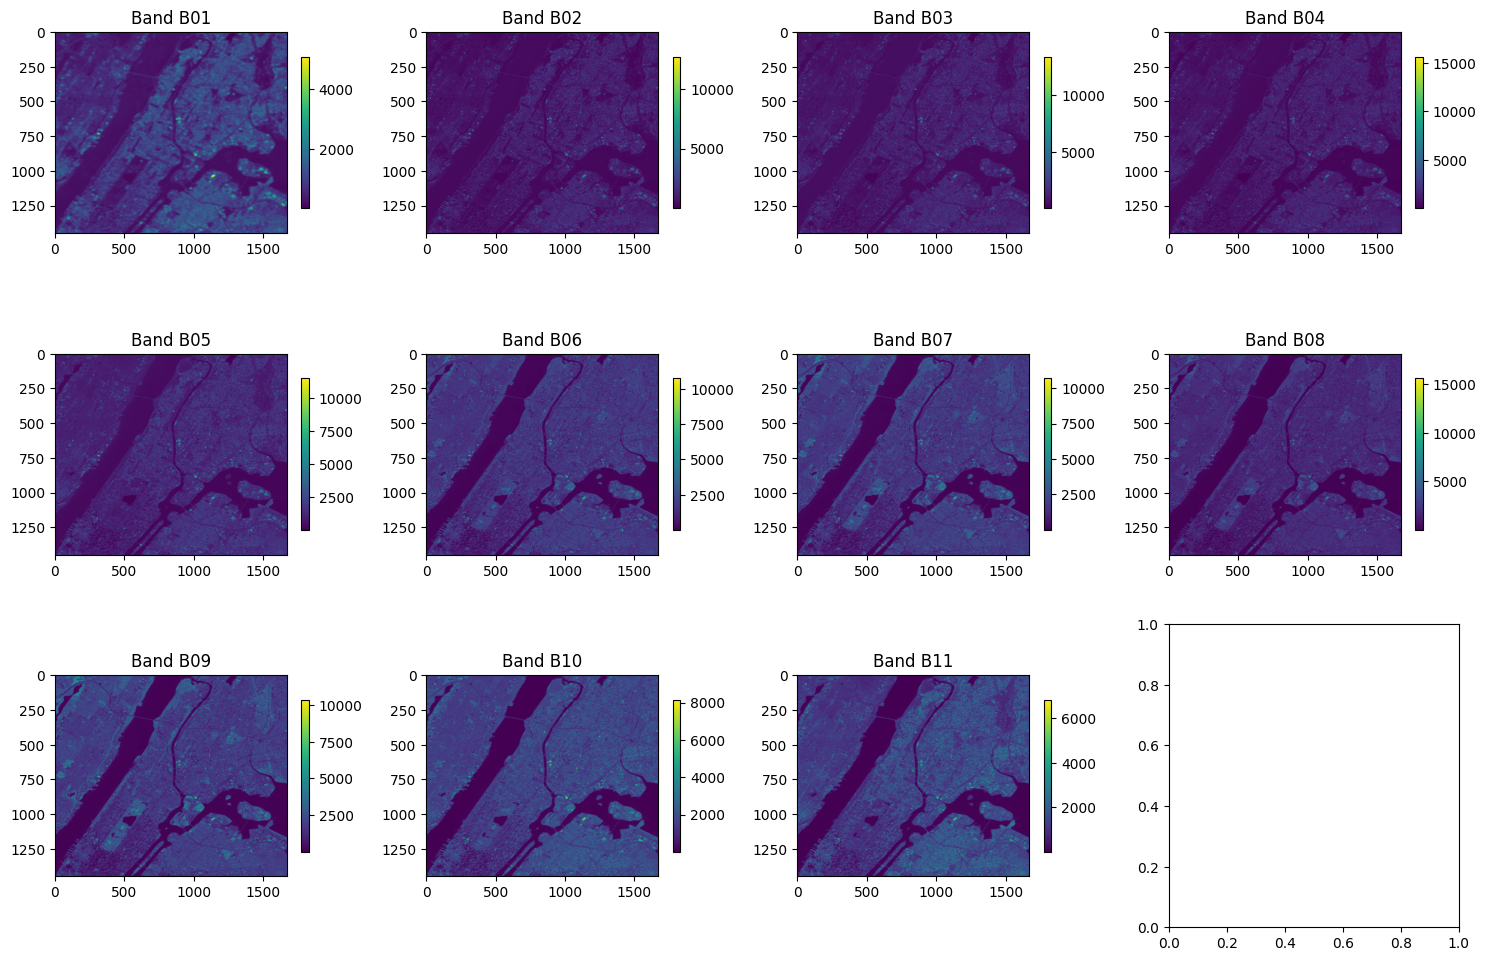

In [ ]:

# Open the GeoTIFF file
Sentinel = "/content/drive/My Drive/DATA/medianSentinel.tiff"  # Replace with your actual file path

# Read all bands from the GeoTIFF file
with rasterio.open(Sentinel) as src:
    num_bands = src.count  # Get the total number of bands

    # Create a figure and axes for the plots
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))  # 3 rows, 4 columns for 12 bands
    axes = axes.flatten()  # Flatten for easier indexing

    # Loop through each band and plot
    for i in range(num_bands):
        band_data = src.read(i + 1)  # Read band data (bands are indexed from 1)

        # Plot the band
        im = axes[i].imshow(band_data, cmap='viridis')
        axes[i].set_title(f'Band B{i+1:02}')  # Format band title (e.g., B01, B02)
        fig.colorbar(im, ax=axes[i], shrink=0.5)  # Add colorbar, shrink if needed

plt.tight_layout()
plt.show()

# Landsat LST Data extraction

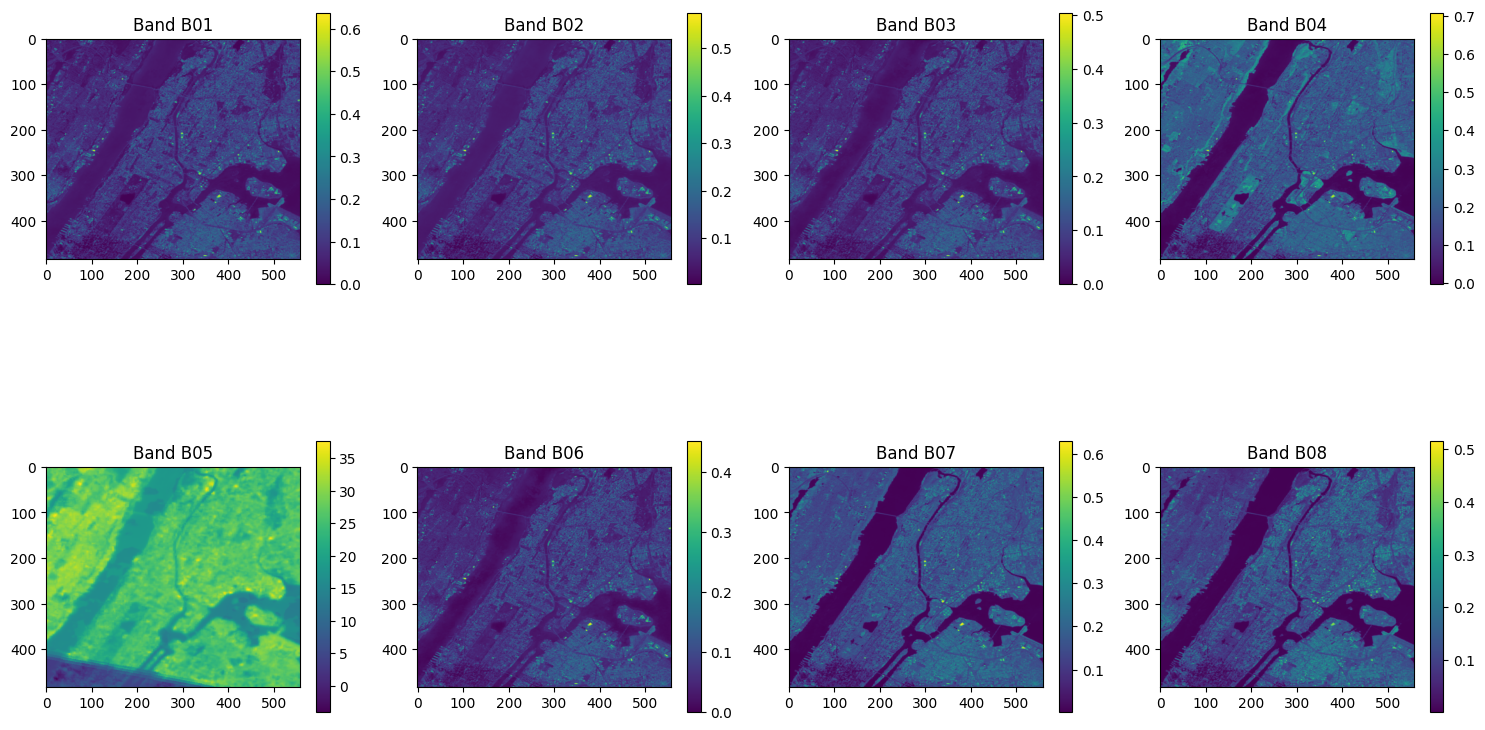

In [ ]:
# Open the GeoTIFF file
Landsat = "/content/drive/My Drive/DATA/medianLandsat.tiff"  # Replace with your actual file path

# Read the single band from the GeoTIFF file
with rasterio.open(Landsat) as src:
    num_bands = src.count  # Get the total number of bands

    # Create a figure and axes for the plots
    fig, axes = plt.subplots(2, 4, figsize=(15, 10))  # 3 rows, 4 columns for 12 bands
    axes = axes.flatten()  # Flatten for easier indexing

    # Loop through each band and plot
    for i in range(num_bands):
        band_data = src.read(i + 1)  # Read band data (bands are indexed from 1)

        # Plot the band
        im = axes[i].imshow(band_data, cmap='viridis')
        axes[i].set_title(f'Band B{i+1:02}')  # Format band title (e.g., B01, B02)
        fig.colorbar(im, ax=axes[i], shrink=0.5)  # Add colorbar, shrink if needed

plt.tight_layout()
plt.show()

In [ ]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.

def map_satellite_data(Landsat, Sentinel , csv_path):

    # Load the GeoTIFF data (sentinel)
    sentinel_data = rxr.open_rasterio(Sentinel)
    sentinel_crs = sentinel_data.rio.crs

    #Load the Geotiff data for Landsat
    landsat_data = rxr.open_rasterio(Landsat)
    landsat_crs = landsat_data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    print("Resampling Sentinel-2...")
    sentinel_resampled = sentinel_data.rio.reproject_match(
        landsat_data,
        resampling=Resampling.bilinear
    )

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_sentinel = Proj(sentinel_crs)
    proj_landsat = Proj(landsat_crs)

    # Create a transformer object (Sentinel)
    transformer_sentinel = Transformer.from_proj(proj_wgs84, proj_sentinel)
    transformer_landsat = Transformer.from_proj(proj_wgs84, proj_landsat)

    B01_values = []
    B02_values = []
    B03_values = []
    B04_values = []
    B05_values = []
    B06_values = []
    B07_values = []
    B08_values = []
    B8A_values = []
    B09_values = []
    B11_values = []
    B12_values = []
    landsat_red =[]
    landsat_green=[]
    landsat_blue=[]
    landsat_nir08=[]
    lwir11_values = []
    landsat_coastal=[]
    landsat_swir16=[]
    landsat_swir22=[]

# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)
    # Convert lat/lon to Sentinel CRS
        x_sen, y_sen = transformer_sentinel.transform(lat, lon)

        # Convert lat/lon to Landsat CRS
        x_landsat, y_landsat = transformer_landsat.transform(lat, lon)

        B01_value = sentinel_data.sel(x=x_sen, y=y_sen,  band=1, method="nearest").values
        B01_values.append(B01_value)

        B02_value = sentinel_data.sel(x=x_sen, y=y_sen, band=2, method="nearest").values
        B02_values.append(B02_value)

        B03_value = sentinel_data.sel(x=x_sen, y=y_sen, band=3, method="nearest").values
        B03_values.append(B03_value)

        B04_value = sentinel_data.sel(x=x_sen, y=y_sen, band=4, method="nearest").values
        B04_values.append(B04_value)

        B05_value = sentinel_data.sel(x=x_sen, y=y_sen, band=5, method="nearest").values
        B05_values.append(B05_value)

        B06_value = sentinel_data.sel(x=x_sen, y=y_sen, band=6, method="nearest").values
        B06_values.append(B06_value)

        B07_value = sentinel_data.sel(x=x_sen, y=y_sen, band=7, method="nearest").values
        B07_values.append(B07_value)

        B08_value = sentinel_data.sel(x=x_sen, y=y_sen, band=8, method="nearest").values
        B08_values.append(B08_value)

        B8A_value = sentinel_data.sel(x=x_sen, y=y_sen, band=9, method="nearest").values
        B8A_values.append(B8A_value)

        B09_value = sentinel_data.sel(x=x_sen, y=y_sen, band=10, method="nearest").values
        B09_values.append(B09_value)

        B11_value = sentinel_data.sel(x=x_sen, y=y_sen, band=11, method="nearest").values
        B11_values.append(B11_value)

        B12_value = sentinel_data.sel(x=x_sen, y=y_sen, band=12, method="nearest").values
        B12_values.append(B12_value)

        # Extract Landsat LWIR11 band value
        landsat_red.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=1, method="nearest").values)
        landsat_green.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=2, method="nearest").values)
        landsat_blue.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=3, method="nearest").values)
        landsat_nir08.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=4, method="nearest").values)
        lwir11_values.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=5, method="nearest").values)
        landsat_coastal.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=6, method="nearest").values)
        landsat_swir16.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=7, method="nearest").values)
        landsat_swir22.append(landsat_data.sel(x=x_landsat, y=y_landsat, band=8, method="nearest").values)

    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df_sentinel = pd.DataFrame()
    df['B01'] = B01_values
    df['B02'] = B02_values
    df['B03'] = B03_values
    df['B04'] = B04_values
    df['B05'] = B05_values
    df['B06'] = B06_values
    df['B07'] = B07_values
    df['B08'] = B08_values
    df['B8A'] = B8A_values
    df['B09'] = B09_values
    df['B11'] = B11_values
    df['B12'] = B12_values
    df['Landsat_Red'] = landsat_red
    df['Landsat_Green'] = landsat_green
    df['Landsat_Blue'] = landsat_blue
    df['Landsat_NIR08'] = landsat_nir08
    df['LWIR11'] = lwir11_values
    df['Landsat_SWIR16'] = landsat_swir16
    df['Landsat_SWIR22'] = landsat_swir22

    # Return the DataFrame with the band values

    return df


In [ ]:
# Mapping satellite data with training data.
final_data = map_satellite_data('/content/drive/My Drive/DATA/medianLandsat.tiff', '/content/drive/My Drive/DATA/medianSentinel.tiff' ,'/content/drive/My Drive/DATA/Training_data_uhi_index_2025-02-18.csv')

Resampling Sentinel-2...


Mapping values: 100%|██████████| 11229/11229 [04:27<00:00, 42.02it/s]


In [ ]:
final_data.head()

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,...,B09,B11,B12,Landsat_Red,Landsat_Green,Landsat_Blue,Landsat_NIR08,LWIR11,Landsat_SWIR16,Landsat_SWIR22
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,629.0,601.0,722.0,804.0,1042.0,1092.0,...,1286.0,1118.0,1118.0,0.058445,0.056891250000000004,0.050318749999999995,0.09253125000000001,27.297339170000015,0.08001875,0.06697
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,629.0,601.0,722.0,804.0,1042.0,1092.0,...,1286.0,1118.0,1118.0,0.058445,0.056891250000000004,0.050318749999999995,0.09253125000000001,27.297339170000015,0.08001875,0.06697
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,629.0,590.0,785.0,744.0,1001.0,1330.0,...,1253.0,970.0,970.0,0.0711775,0.07109500000000002,0.05337125000000001,0.147765,25.685742740000023,0.10973250000000001,0.07911125
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,629.0,519.0,688.0,687.0,1001.0,1330.0,...,1253.0,970.0,970.0,0.0711775,0.07109500000000002,0.05337125000000001,0.147765,25.685742740000023,0.10973250000000001,0.07911125
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,629.0,522.0,705.0,712.0,975.0,1389.0,...,1290.0,1026.0,1026.0,0.091335,0.08703125,0.06596625,0.16887125,25.64985353000003,0.14134375000000002,0.103655


In [ ]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
# See the Sentinel-2 sample notebook for more information about the NDVI index
final_data['NDVI'] = (final_data['B08'] - final_data['B04']) / (final_data['B08'] + final_data['B04'])
final_data['NDVI'] = final_data['NDVI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
final_data['NDWI'] = (final_data['B03'] - final_data['B08']) / (final_data['B03'] + final_data['B08'])
final_data['NDWI'] = final_data['NDWI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
final_data['NDMI'] = (final_data['B08'] - final_data['B11']) / (final_data['B08'] + final_data['B11'])
final_data['NDMI'] = final_data['NDMI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
final_data['NDBI'] = (final_data['B11'] - final_data['B08']) / (final_data['B11'] + final_data['B08'])
final_data['NDBI'] = final_data['NDBI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
final_data.head()

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,...,Landsat_Green,Landsat_Blue,Landsat_NIR08,LWIR11,Landsat_SWIR16,Landsat_SWIR22,NDVI,NDWI,NDMI,NDBI
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,629.0,601.0,722.0,804.0,1042.0,1092.0,...,0.056891250000000004,0.050318749999999995,0.09253125000000001,27.297339170000015,0.08001875,0.06697,0.098149,-0.151088,-0.066285,0.066285
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,629.0,601.0,722.0,804.0,1042.0,1092.0,...,0.056891250000000004,0.050318749999999995,0.09253125000000001,27.297339170000015,0.08001875,0.06697,0.098149,-0.151088,-0.066285,0.066285
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,629.0,590.0,785.0,744.0,1001.0,1330.0,...,0.07109500000000002,0.05337125000000001,0.147765,25.685742740000023,0.10973250000000001,0.07911125,0.364103,-0.340613,0.243959,-0.243959
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,629.0,519.0,688.0,687.0,1001.0,1330.0,...,0.07109500000000002,0.05337125000000001,0.147765,25.685742740000023,0.10973250000000001,0.07911125,0.377435,-0.376812,0.220884,-0.220884
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,629.0,522.0,705.0,712.0,975.0,1389.0,...,0.08703125,0.06596625,0.16887125,25.64985353000003,0.14134375000000002,0.103655,0.340741,-0.345100,0.170574,-0.170574


In [ ]:
features_df=final_data.drop(columns=['Latitude','Longitude','datetime'])

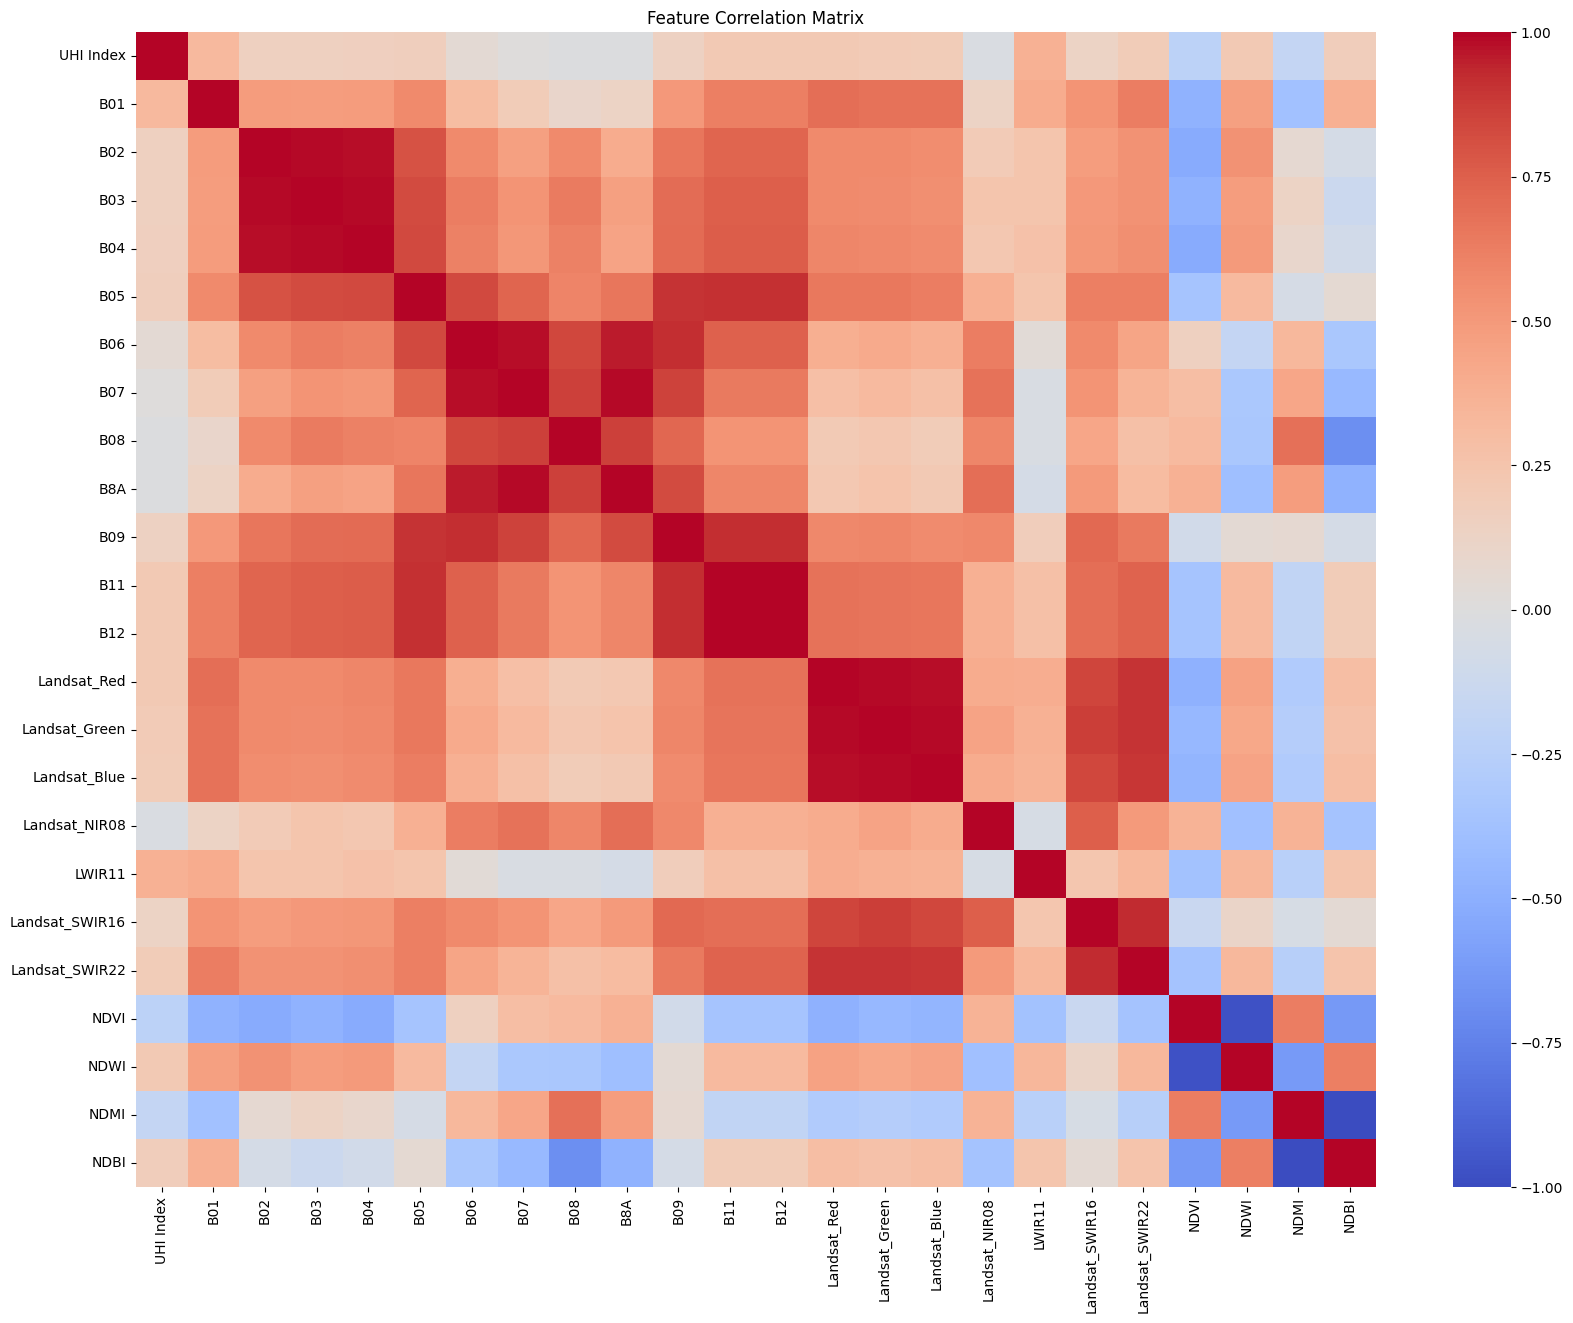

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(features_df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

#Data Processing

In [ ]:
print(final_data.isnull().sum())

Longitude         0
Latitude          0
datetime          0
UHI Index         0
B01               0
B02               0
B03               0
B04               0
B05               0
B06               0
B07               0
B08               0
B8A               0
B09               0
B11               0
B12               0
Landsat_Red       0
Landsat_Green     0
Landsat_Blue      0
Landsat_NIR08     0
LWIR11            0
Landsat_SWIR16    0
Landsat_SWIR22    0
NDVI              0
NDWI              0
NDMI              0
NDBI              0
dtype: int64


#Model Building

In [ ]:
uhi_data = final_data[['NDWI','NDBI','B01','LWIR11','UHI Index']]
uhi_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values in the target variable ('UHI Index')
uhi_data.dropna(subset=['UHI Index'], inplace=True)

In [ ]:
# Split the data into features (X) and target (y), and then into training and testing sets
X = uhi_data.drop(columns=['UHI Index'])
y = uhi_data ['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Feature Scaling
# Scale the training and test data using standardscaler
rc = RobustScaler()
X_train_scaled = rc.fit_transform(X_train)
X_test_scaled = rc.transform(X_test)

In [ ]:
print("Shape of data:", X_train.shape)
print("Total elements:", X_train.size)

Shape of data: (8983, 4)
Total elements: 35932


In [ ]:
xgb_param_grid = {
    'n_estimators': stats.randint(10, 200),
    'max_depth': [6, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 10],
    'reg_alpha': [0, 1]
}

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_grid = RandomizedSearchCV(xgb_model, xgb_param_grid, cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train_scaled, y_train)
best_xgb = xgb_grid.best_estimator_

In [ ]:
rf_param_grid = {
    'n_estimators': stats.randint(10, 200),
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}
rf_model = RandomForestRegressor(random_state=42)
rf_grid = RandomizedSearchCV(rf_model, rf_param_grid, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

In [ ]:
xgb_pred_train = best_xgb.predict(X_train_scaled)
rf_pred_train = best_rf.predict(X_train_scaled)
xgb_pred_test = best_xgb.predict(X_test_scaled)
rf_pred_test = best_rf.predict(X_test_scaled)

In [ ]:
stacked_train = np.column_stack((xgb_pred_train, rf_pred_train))
stacked_test = np.column_stack((xgb_pred_test, rf_pred_test))

In [ ]:
meta_param_grid = {
    'n_estimators': stats.randint(10, 200),
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

meta_model = RandomForestRegressor(random_state=42)

meta_grid = RandomizedSearchCV(meta_model, meta_param_grid, cv=5, scoring='r2', n_jobs=-1)
meta_grid.fit(stacked_train, y_train)
best_meta = meta_grid.best_estimator_

In [ ]:
final_pred = best_meta.predict(stacked_test)

In [ ]:
def evaluate_predictions(y_true, y_pred, model_name="Model"):
    """Helper function to print R², MAE, and RMSE."""
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} Performance:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  Root Mean Squared Error (RMSE): {rmse:.4f}")
    print("-"*50)

# ========== 1) XGBoost In-sample vs. Out-of-sample ==========
xgb_pred_train = best_xgb.predict(X_train_scaled)   # in-sample
xgb_pred_test = best_xgb.predict(X_test_scaled)     # out-of-sample

evaluate_predictions(y_train, xgb_pred_train, "XGBoost (Train)")
evaluate_predictions(y_test, xgb_pred_test, "XGBoost (Test)")

# ========== 2) Random Forest In-sample vs. Out-of-sample ==========
rf_pred_train = best_rf.predict(X_train_scaled)     # in-sample
rf_pred_test = best_rf.predict(X_test_scaled)       # out-of-sample

evaluate_predictions(y_train, rf_pred_train, "Random Forest (Train)")
evaluate_predictions(y_test, rf_pred_test, "Random Forest (Test)")

# ========== 3) Stacked Ensemble In-sample vs. Out-of-sample ==========

# Assuming you built a meta model using stacked features.
# Let's say 'stacked_train' are the meta-features for the training set,
# and 'stacked_test' are the meta-features for the test set.

meta_pred_train = best_meta.predict(stacked_train)  # in-sample
meta_pred_test = best_meta.predict(stacked_test)    # out-of-sample

evaluate_predictions(y_train, meta_pred_train, "Stacked Ensemble (Train)")
evaluate_predictions(y_test, meta_pred_test, "Stacked Ensemble (Test)")

XGBoost (Train) Performance:
  R² Score: 0.9857
  Mean Absolute Error (MAE): 0.0014
  Root Mean Squared Error (RMSE): 0.0019
--------------------------------------------------
XGBoost (Test) Performance:
  R² Score: 0.7407
  Mean Absolute Error (MAE): 0.0057
  Root Mean Squared Error (RMSE): 0.0083
--------------------------------------------------
Random Forest (Train) Performance:
  R² Score: 0.9753
  Mean Absolute Error (MAE): 0.0017
  Root Mean Squared Error (RMSE): 0.0026
--------------------------------------------------
Random Forest (Test) Performance:
  R² Score: 0.7250
  Mean Absolute Error (MAE): 0.0060
  Root Mean Squared Error (RMSE): 0.0085
--------------------------------------------------
Stacked Ensemble (Train) Performance:
  R² Score: 0.9925
  Mean Absolute Error (MAE): 0.0010
  Root Mean Squared Error (RMSE): 0.0014
--------------------------------------------------
Stacked Ensemble (Test) Performance:
  R² Score: 0.7529
  Mean Absolute Error (MAE): 0.0055
  Root Me

#Training Model

In [ ]:
testfile_path = '/content/drive/My Drive/DATA/Submission_template_UHI2025-v2.csv'  # Update with your file's path in Drive
test_df = pd.read_csv(testfile_path)
test_df.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,NaN
1,-73.971928,40.788875,NaN
2,-73.967080,40.789080,NaN
3,-73.972550,40.789082,NaN
4,-73.969697,40.787953,NaN


In [ ]:
# Mapping satellite data for submission.
val_data =  map_satellite_data('/content/drive/My Drive/DATA/medianLandsat.tiff', '/content/drive/My Drive/DATA/medianSentinel.tiff' ,'/content/drive/My Drive/DATA/Submission_template_UHI2025-v2.csv')

Resampling Sentinel-2...


Mapping values: 100%|██████████| 1040/1040 [00:24<00:00, 42.02it/s]


In [ ]:
# Calculate NDVI (Normalized Difference Vegetation Index) and handle division by zero by replacing infinities with NaN.
val_data['NDVI'] = (val_data['B08'] - val_data['B04']) / (val_data['B08'] + val_data['B04'])
val_data['NDVI'] = val_data['NDVI'].replace([np.inf, -np.inf], np.nan)  # Replace infinities with NaN

In [ ]:
val_data['NDWI'] = (val_data['B03'] - val_data['B08']) / (val_data['B03'] + val_data['B08'])
val_data['NDWI'] = val_data['NDWI'].replace([np.inf, -np.inf], np.nan)
val_data['NDMI'] = (val_data['B08'] - val_data['B11']) / (val_data['B08'] + val_data['B11'])
val_data['NDMI'] = val_data['NDMI'].replace([np.inf, -np.inf], np.nan)
val_data['NDBI'] = (val_data['B11'] - val_data['B08']) / (val_data['B11'] + val_data['B08'])
final_data['NDBI'] = val_data['NDBI'].replace([np.inf, -np.inf], np.nan)

In [ ]:
val_data.head()

,Longitude,Latitude,UHI Index,B01,B02,B03,B04,B05,B06,B07,...,Landsat_Green,Landsat_Blue,Landsat_NIR08,LWIR11,Landsat_SWIR16,Landsat_SWIR22,NDVI,NDWI,NDMI,NDBI
0,-73.971665,40.788763,NaN,583.0,397.0,521.0,502.0,844.0,1396.0,1584.0,...,0.06952749999999999,0.049920000000000006,0.21327,25.24823618000002,0.13829125,0.0984025,0.473242,-0.458701,0.242478,-0.242478
1,-73.971928,40.788875,NaN,970.0,562.0,733.0,791.0,1334.0,2039.0,2248.0,...,0.06952749999999999,0.049920000000000006,0.21327,25.24823618000002,0.13829125,0.0984025,0.575074,-0.600000,0.359926,-0.359926
2,-73.967080,40.789080,NaN,601.0,435.0,476.0,453.0,449.0,549.0,530.0,...,0.079565,0.06753375,0.1075325,23.48966489000003,0.112675,0.09558375000000002,0.110893,-0.086372,0.017071,-0.017071
3,-73.972550,40.789082,NaN,887.0,490.0,483.0,616.0,1160.0,1218.0,1294.0,...,0.11262,0.09467625000000002,0.17324375,25.388375000000025,0.17532,0.160305,0.092784,-0.211429,-0.286538,0.286538
4,-73.969697,40.787953,NaN,766.0,659.0,704.0,739.0,949.0,1298.0,1377.0,...,0.1234275,0.10654249999999998,0.2251775,23.31363686000003,0.19644,0.15789875,0.368106,-0.388889,0.159000,-0.159


In [ ]:
# Extracting specific columns (B01, B06, and NDVI) from the validation dataset
submission_val_data=val_data.loc[:,['NDWI','NDBI','B01','LWIR11']]
submission_val_data.head()

,NDWI,NDBI,B01,LWIR11
0,-0.458701,-0.242478,583.0,25.24823618000002
1,-0.600000,-0.359926,970.0,25.24823618000002
2,-0.086372,-0.017071,601.0,23.48966489000003
3,-0.211429,0.286538,887.0,25.388375000000025
4,-0.388889,-0.159,766.0,23.31363686000003


In [ ]:
submission_val_data = submission_val_data.values
transformed_submission_data = rc.transform(submission_val_data)

In [ ]:
xgb_pred_submission = best_xgb.predict(transformed_submission_data)
rf_pred_submission = best_rf.predict(transformed_submission_data)

# Stack the predictions to create the input for the meta-model
stacked_submission = np.column_stack((xgb_pred_submission, rf_pred_submission))

# Now make predictions using the meta-model
final_predictions = best_meta.predict(stacked_submission)
final_prediction_series = pd.Series(final_predictions)

In [ ]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'Longitude':test_df['Longitude'].values, 'Latitude':test_df['Latitude'].values, 'UHI Index':final_prediction_series.values})

In [ ]:
#Displaying the sample submission dataframe
submission_df.head()

,Longitude,Latitude,UHI Index
0,-73.971665,40.788763,0.962580
1,-73.971928,40.788875,0.963899
2,-73.967080,40.789080,0.979401
3,-73.972550,40.789082,0.975009
4,-73.969697,40.787953,0.958926


In [ ]:
#Dumping the predictions into a csv file.
submission_df.to_csv("submission3.csv",index = False)